# Telangana PDS Analytics: Multi-Dimensional Shop Performance Clustering and Anomaly Profiling

**Project Overview:**
This project integrates 3.5 years of transactional, card status, and geospatial data from the Telangana State Civil Supplies Department. It cleanses the data, builds shop-level features, handles scaling/imputation through pipelines, and performs clustering (K-Means) and anomaly detection (DBSCAN).

---

## Section 1: Environment Setup & Library Imports

In [ ]:
import os
import warnings
from pathlib import Path

import folium
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (calinski_harabasz_score,davies_bouldin_score,silhouette_score,)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Environment ready.")

Pandas version: 2.2.3
NumPy version: 2.1.3
Environment ready.


## Section 2: Mount Google Drive & Define Directories

In [ ]:
# Mount Google Drive
drive.mount("/content/drive", force_remount=True)

# Define base project path and subdirectories
PROJECT_DIR = Path("/content/drive/MyDrive/Telangana_PDS_Project")
RAW_DIR = PROJECT_DIR / "raw"
LOCATION_DIR = PROJECT_DIR / "table1_locations"
CARD_DIR = PROJECT_DIR / "table2_card_status"
TRANSACTION_DIR = PROJECT_DIR / "table3_transactions"

MASTER_DIR = PROJECT_DIR / "master"
PROCESSED_DIR = PROJECT_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "figures"
REPORT_DIR = PROJECT_DIR / "reports"

# Create directories if they do not exist
for folder in [MASTER_DIR, PROCESSED_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR, LOCATION_DIR, CARD_DIR, TRANSACTION_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project Directory Initialized:", PROJECT_DIR)

Mounted at /content/drive
Project Directory Initialized: /content/drive/MyDrive/Telangana_PDS_Project


## Section 3: Safe Data Ingestion & Cleansing Helpers

In [ ]:
def read_csv_safe(file_path):
    """Safely reads CSV handling character encoding errors."""
    try:
        return pd.read_csv(file_path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding="latin1", low_memory=False)

def clean_column_names(df):
    """Standardizes column headers by removing whitespace and special characters."""
    df = df.copy()
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")
    return df

def clean_text_columns(df):
    """Strips leading/trailing whitespaces from string columns."""
    df = df.copy()
    text_columns = df.select_dtypes(include=["object"]).columns
    for col in text_columns:
        df[col] = df[col].astype("string").str.strip()
    return df

# Scan available input CSV files
location_files = sorted(LOCATION_DIR.glob("*.csv"))
card_files = sorted(CARD_DIR.glob("*.csv"))
transaction_files = sorted(TRANSACTION_DIR.glob("*.csv"))

print("Location files   :", len(location_files))
print("Card Status files:", len(card_files))
print("Transaction files:", len(transaction_files))

Location files   : 1
Card Status files: 30
Transaction files: 29


## Section 4: Build & Consolidate Master Datasets

In [ ]:
if location_files and card_files and transaction_files:
    print("Consolidating raw CSV files...")

    # Build Master Transactions
    trans_list = [clean_text_columns(clean_column_names(read_csv_safe(f))) for f in transaction_files]
    transactions_master = pd.concat(trans_list, ignore_index=True)

    # Build Master Cards
    card_list = [clean_text_columns(clean_column_names(read_csv_safe(f))) for f in card_files]
    card_master = pd.concat(card_list, ignore_index=True)

    # Build Master Locations
    locations_master = clean_text_columns(clean_column_names(read_csv_safe(location_files[0])))

    # Save master files as Parquet
    transactions_master.to_parquet(MASTER_DIR / "transactions_master.parquet", index=False)
    card_master.to_parquet(MASTER_DIR / "card_status_master.parquet", index=False)
    locations_master.to_parquet(MASTER_DIR / "locations_master.parquet", index=False)
else:
    print("Loading existing parquet master files...")
    transactions_master = pd.read_parquet(MASTER_DIR / "transactions_master.parquet")
    card_master = pd.read_parquet(MASTER_DIR / "card_status_master.parquet")
    locations_master = pd.read_parquet(MASTER_DIR / "locations_master.parquet")

# Enforce numerical types on key identifiers
key_cols = ["distCode", "officeCode", "shopNo", "month", "year"]
for col in key_cols:
    if col in transactions_master.columns:
        transactions_master[col] = pd.to_numeric(transactions_master[col], errors="coerce").astype("Int64")
    if col in card_master.columns:
        card_master[col] = pd.to_numeric(card_master[col], errors="coerce").astype("Int64")
    if col in locations_master.columns:
        locations_master[col] = pd.to_numeric(locations_master[col], errors="coerce").astype("Int64")

for col in ["latitude", "longitude"]:
    if col in locations_master.columns:
        locations_master[col] = pd.to_numeric(locations_master[col], errors="coerce")

# Construct Standardized Date Columns
transactions_master["date"] = pd.to_datetime(dict(year=transactions_master["year"], month=transactions_master["month"], day=1), errors="coerce")
card_master["date"] = pd.to_datetime(dict(year=card_master["year"], month=card_master["month"], day=1), errors="coerce")

# Deduplicate prior to merging to prevent row duplication
merge_keys = ["distCode", "shopNo", "year", "month"]
transactions_master = transactions_master.drop_duplicates(subset=merge_keys)
card_master = card_master.drop_duplicates(subset=merge_keys)
locations_master = locations_master.drop_duplicates(subset=["distCode", "shopNo"])

# Merge Into Integrated Shop-Month Master
shop_month = transactions_master.merge(locations_master, on=["distCode", "shopNo"], how="left", suffixes=("", "_loc"))
shop_month = shop_month.merge(card_master, on=merge_keys, how="left", suffixes=("", "_card"))

print("Integrated Dataset Shape:", shop_month.shape)
display(shop_month.head())

Consolidating raw CSV files...
Integrated Dataset Shape: (499648, 54)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,...,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType,date_card
0,532,Adilabad,532001,Talamadugu,1901001,10,2023,956,956,1365.0,...,150.0,308.0,1108.0,3392.0,NaN,0.0,0.0,NaN,NaN,2023-10-01
1,532,Adilabad,532001,Talamadugu,1901002,10,2023,520,522,700.0,...,306.0,737.0,584.0,1877.0,NaN,0.0,0.0,NaN,NaN,2023-10-01
2,532,Adilabad,532001,Talamadugu,1901003,10,2023,266,266,595.0,...,117.0,296.0,292.0,952.0,NaN,0.0,0.0,NaN,NaN,2023-10-01
3,532,Adilabad,532001,Talamadugu,1901004,10,2023,368,369,490.0,...,201.0,526.0,405.0,1348.0,NaN,0.0,0.0,NaN,NaN,2023-10-01
4,532,Adilabad,532001,Talamadugu,1901005,10,2023,914,914,5355.0,...,286.0,747.0,970.0,3328.0,NaN,0.0,0.0,NaN,NaN,2023-10-01


## Section 5: Exploratory Data Analysis (EDA)

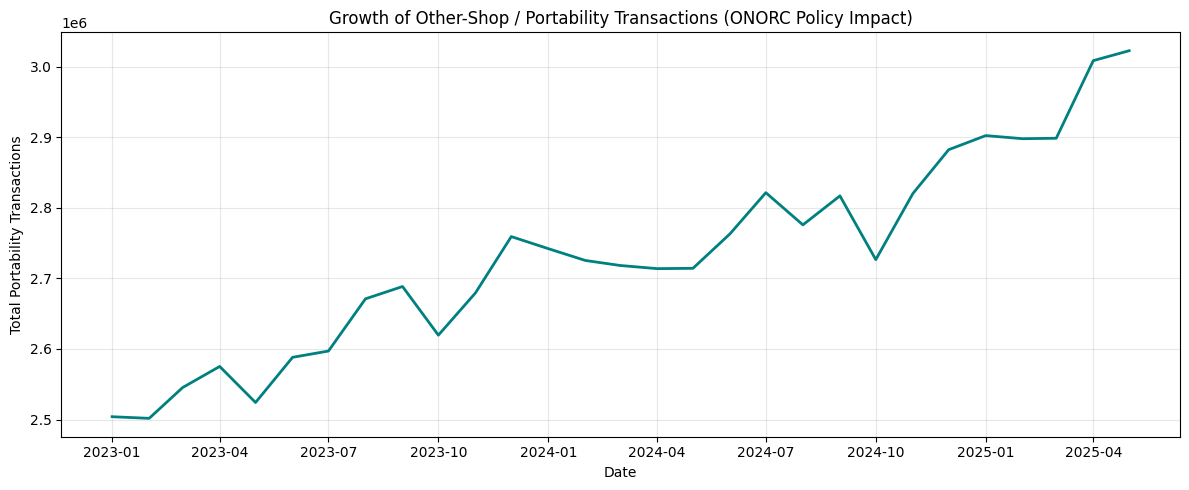

In [ ]:
# 1. Portability Trend Over Time
monthly_portability = shop_month.groupby("date")["otherShopTransCnt"].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_portability.index, monthly_portability.values, color="teal", linewidth=2)
plt.title("Growth of Other-Shop / Portability Transactions (ONORC Policy Impact)")
plt.xlabel("Date")
plt.ylabel("Total Portability Transactions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "portability_trend.png")
plt.show()

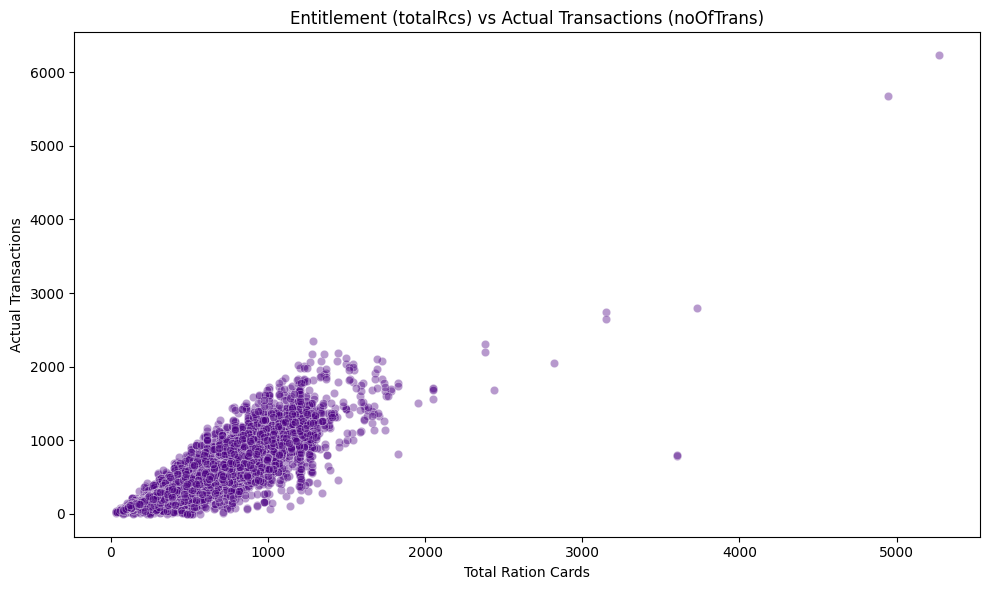

In [ ]:
# 2. Ration Cards vs Execution Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=shop_month.sample(min(20000, len(shop_month)), random_state=42), x="totalRcs", y="noOfTrans", alpha=0.4, color="indigo")
plt.title("Entitlement (totalRcs) vs Actual Transactions (noOfTrans)")
plt.xlabel("Total Ration Cards")
plt.ylabel("Actual Transactions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "entitlement_vs_execution.png")
plt.show()

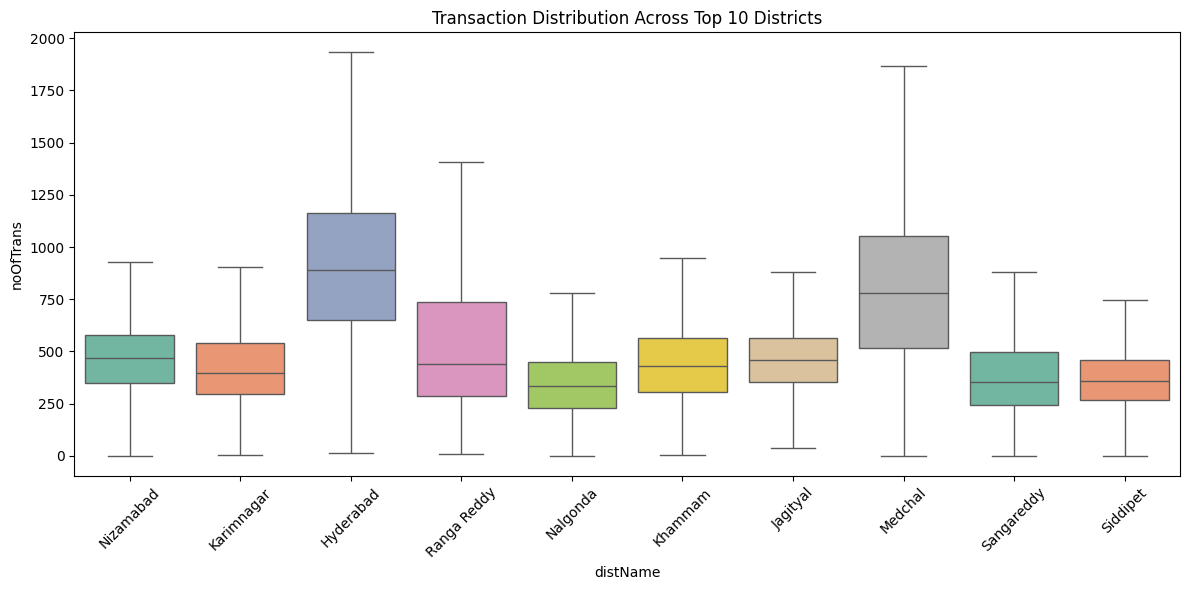

In [ ]:
# 3. Distribution of Transactions Across Major Districts
if "distName" in shop_month.columns:
    top_districts = shop_month.groupby("distName")["noOfTrans"].sum().nlargest(10).index
    plot_df = shop_month[shop_month["distName"].isin(top_districts)]
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="distName", y="noOfTrans", palette="Set2", showfliers=False)
    plt.xticks(rotation=45)
    plt.title("Transaction Distribution Across Top 10 Districts")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "district_transaction_boxplot.png")
    plt.show()

## Section 6: Advanced Feature Engineering & Aggregation

In [ ]:
# Safe division calculations
shop_month["utilization_rate"] = np.where(
    shop_month["totalRcs"] > 0, shop_month["noOfTrans"] / shop_month["totalRcs"], np.nan
)

rice_cols = [c for c in ["riceAfsc", "riceFsc", "riceAap"] if c in shop_month.columns]
shop_month["total_rice"] = shop_month[rice_cols].sum(axis=1)
wheat_col = "wheat" if "wheat" in shop_month.columns else "total_rice"

shop_month["rice_intensity"] = np.where(
    (shop_month["total_rice"] + shop_month[wheat_col]) > 0,
    shop_month["total_rice"] / (shop_month["total_rice"] + shop_month[wheat_col]),
    np.nan
)

shop_month["portability_rate"] = np.where(
    shop_month["noOfTrans"] > 0, shop_month["otherShopTransCnt"] / shop_month["noOfTrans"], np.nan
)

# Shop-level aggregations
shop_features = shop_month.groupby(["distCode", "shopNo"], as_index=False).agg(
    avg_transactions=("noOfTrans", "mean"),
    median_transactions=("noOfTrans", "median"),
    transaction_std=("noOfTrans", "std"),
    avg_cards=("totalRcs", "mean"),
    avg_units=("totalUnits", "mean") if "totalUnits" in shop_month.columns else ("totalRcs", "mean"),
    avg_utilization=("utilization_rate", "mean"),
    avg_portability=("portability_rate", "mean"),
    portability_std=("portability_rate", "std"),
    avg_rice_intensity=("rice_intensity", "mean"),
    total_rice=("total_rice", "sum"),
    total_wheat=(wheat_col, "sum"),
    months_observed=("date", "nunique")
)

# Compute Transaction Growth Feature
shop_month_sorted = shop_month.sort_values(["shopNo", "date"])
first_last = shop_month_sorted.groupby(["distCode", "shopNo"]).agg(
    first_trans=("noOfTrans", "first"), last_trans=("noOfTrans", "last")
).reset_index()

first_last["transaction_growth"] = np.where(
    first_last["first_trans"] > 0,
    (first_last["last_trans"] - first_last["first_trans"]) / first_last["first_trans"],
    0.0
)

shop_features = shop_features.merge(first_last[["distCode", "shopNo", "transaction_growth"]], on=["distCode", "shopNo"], how="left")
shop_features["transaction_std"] = shop_features["transaction_std"].fillna(0)
shop_features["portability_std"] = shop_features["portability_std"].fillna(0)

# Attach spatial metadata
spatial_lookup = locations_master[["distCode", "shopNo", "latitude", "longitude"]].drop_duplicates(subset=["distCode", "shopNo"])
if "distName" in locations_master.columns:
    spatial_lookup["distName"] = locations_master["distName"]
shop_features = shop_features.merge(spatial_lookup, on=["distCode", "shopNo"], how="left")

ml_features = [
    "avg_transactions", "median_transactions", "transaction_std",
    "avg_cards", "avg_units", "avg_utilization", "avg_portability",
    "portability_std", "avg_rice_intensity", "total_rice", "total_wheat",
    "transaction_growth", "months_observed"
]

X = shop_features[ml_features].copy().replace([np.inf, -np.inf], np.nan)
print("ML Feature Matrix Shape:", X.shape)
display(X.isnull().sum().to_frame("Missing Values"))

ML Feature Matrix Shape: (17491, 13)


,Missing Values
avg_transactions,0
median_transactions,0
transaction_std,0
avg_cards,0
avg_units,0
avg_utilization,0
avg_portability,0
portability_std,0
avg_rice_intensity,0
total_rice,0


## Section 7: ML Pipeline, Scaling, Imputation & PCA

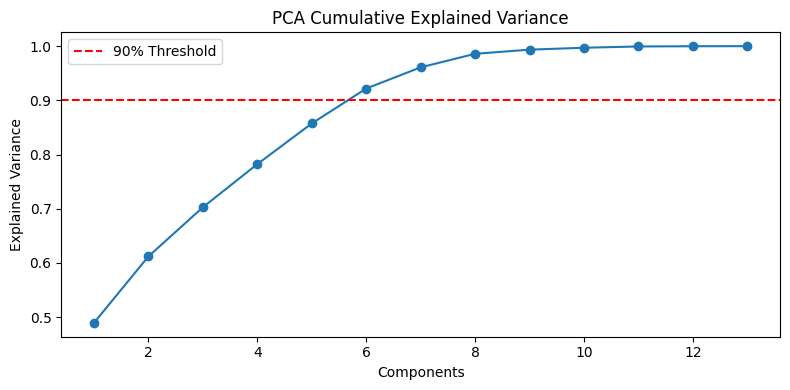

In [ ]:
# Scikit-Learn Pipeline to eliminate data leakage
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessing_pipeline.fit_transform(X)

# PCA Variance Analysis
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.90, color="r", linestyle="--", label="90% Threshold")
plt.xlabel("Components")
plt.ylabel("Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_variance.png")
plt.show()

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

## Section 8: K-Means Behavioral Clustering

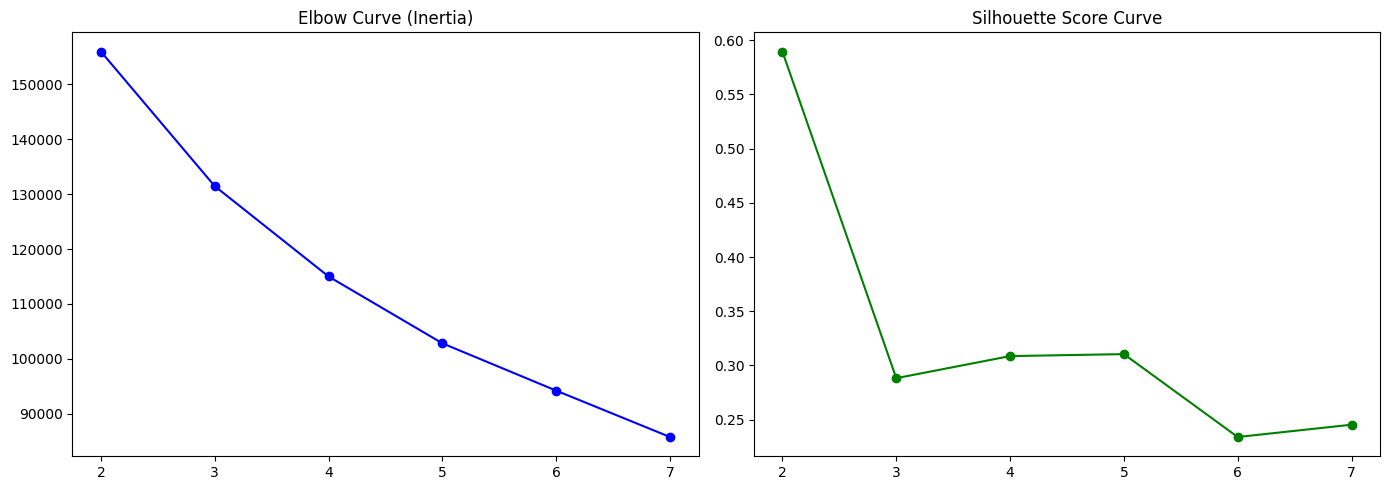

=== K-Means Validation Metrics ===
Silhouette Score    : 0.3087
Davies-Bouldin Score: 1.1168
Calinski-Harabasz   : 5696.59


,avg_transactions,median_transactions,transaction_std,avg_cards,avg_units,avg_utilization,avg_portability,portability_std,avg_rice_intensity,total_rice,total_wheat,transaction_growth,months_observed
cluster,,,,,,,,,,,,,
0,297.823,298.283,19.201,385.305,1178.257,0.784,0.185,0.033,0.999,173729.883,101.305,0.181,28.949
1,1056.945,1063.228,119.516,1042.465,3646.845,1.026,0.749,0.023,0.892,671172.172,76783.448,0.286,28.915
2,600.765,603.034,40.461,677.981,2104.753,0.901,0.375,0.027,0.997,352269.967,1086.994,0.137,28.967
3,356.985,370.205,60.598,469.689,1471.681,0.803,0.263,0.112,0.996,84501.088,200.791,0.118,11.491


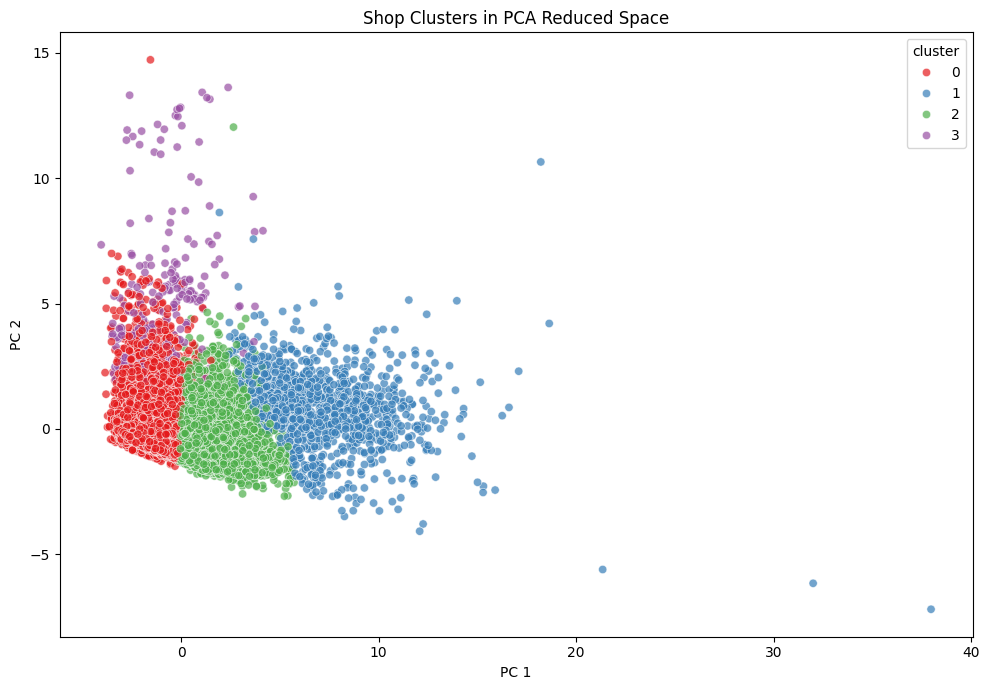

In [ ]:
# Determine optimal K
k_range = range(2, 8)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_range), inertias, marker="o", color="b")
ax[0].set_title("Elbow Curve (Inertia)")
ax[1].plot(list(k_range), silhouettes, marker="o", color="g")
ax[1].set_title("Silhouette Score Curve")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_evaluation.png")
plt.show()

# Fit Optimal K-Means Model (K=4)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
shop_features["cluster"] = kmeans_final.fit_predict(X_scaled)

# Calculate Metrics
print("=== K-Means Validation Metrics ===")
print(f"Silhouette Score    : {silhouette_score(X_scaled, shop_features['cluster']):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_scaled, shop_features['cluster']):.4f}")
print(f"Calinski-Harabasz   : {calinski_harabasz_score(X_scaled, shop_features['cluster']):.2f}")

# Cluster Profiling Summary
cluster_profile = shop_features.groupby("cluster")[ml_features].mean().round(3)
display(cluster_profile)
cluster_profile.to_csv(REPORT_DIR / "cluster_profile.csv")

# Plot Clusters in PCA Space
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=shop_features["cluster"], palette="Set1", alpha=0.7)
plt.title("Shop Clusters in PCA Reduced Space")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_clusters.png")
plt.show()

## Section 9: DBSCAN Anomaly Profiling

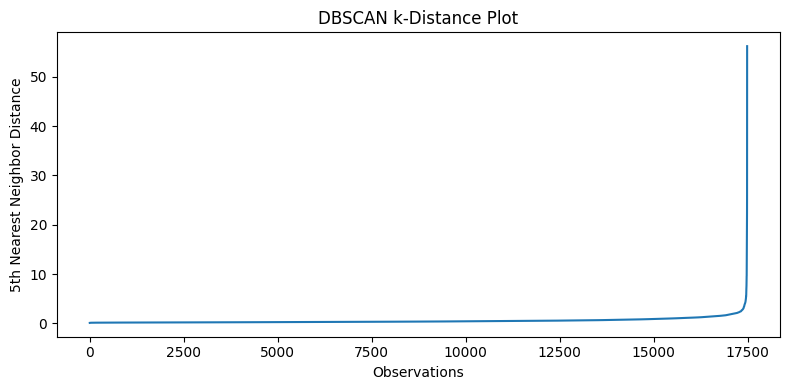

DBSCAN Label Counts:
dbscan_label
 0     16944
-1       455
 1        46
 9         8
 2         7
 8         6
 10        6
 3         5
 4         5
 6         4
 7         3
 5         2
Name: count, dtype: int64

Top Deviations in Outlier Shops:


,Anomaly_Mean,Normal_Mean,Difference
total_rice,426219.008791,255957.503052,170261.505739
total_wheat,31145.670330,4893.645163,26252.025166
avg_units,2937.935368,1602.334778,1335.600590
avg_cards,877.893683,512.282028,365.611655
median_transactions,750.264835,437.347441,312.917394
avg_transactions,738.805779,435.914740,302.891039
transaction_std,154.212644,30.214153,123.998491
months_observed,24.195604,28.682731,-4.487126
transaction_growth,4.122648,0.067708,4.054940
avg_portability,0.646508,0.273560,0.372949


In [ ]:
# k-Distance plot for DBSCAN epsilon tuning
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("DBSCAN k-Distance Plot")
plt.xlabel("Observations")
plt.ylabel("5th Nearest Neighbor Distance")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_kdistance.png")
plt.show()

# Fit DBSCAN Model
dbscan = DBSCAN(eps=1.5, min_samples=5)
shop_features["dbscan_label"] = dbscan.fit_predict(X_scaled)

print("DBSCAN Label Counts:")
print(shop_features["dbscan_label"].value_counts())

# Anomaly Profiling Summary
anomalies = shop_features[shop_features["dbscan_label"] == -1]
normal = shop_features[shop_features["dbscan_label"] != -1]

anomaly_summary = pd.DataFrame({
    "Anomaly_Mean": anomalies[ml_features].mean(),
    "Normal_Mean": normal[ml_features].mean()
})
anomaly_summary["Difference"] = anomaly_summary["Anomaly_Mean"] - anomaly_summary["Normal_Mean"]
print("\nTop Deviations in Outlier Shops:")
display(anomaly_summary.sort_values("Difference", key=abs, ascending=False))

## Section 10: Model Export & Artifact Saving

In [ ]:
# Export models
joblib.dump(preprocessing_pipeline, MODEL_DIR / "preprocessing_pipeline.joblib")
joblib.dump(kmeans_final, MODEL_DIR / "kmeans_model.joblib")
joblib.dump(pca_2d, MODEL_DIR / "pca_2d_model.joblib")

# Export processed dataset with cluster labels
shop_features.to_parquet(PROCESSED_DIR / "shop_features_with_clusters.parquet", index=False)

print("All models and datasets exported successfully to:", PROCESSED_DIR)

All models and datasets exported successfully to: /content/drive/MyDrive/Telangana_PDS_Project/processed
